# Used Automobile Analysis

## Objective
Analyze used car listings to identify pricing patterns,
market trends, vehicle condition effects, and regional sales performance.

## Dataset
car_prices.csv

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [6]:
# Import Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from google.colab import files

uploaded = files.upload()

Saving car_prices.csv to car_prices.csv


In [8]:
# Load dataset

df_car_prices = pd.read_csv('/content/car_prices.csv')

In [9]:
# Display first 5 rows

df_car_prices.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [10]:
df_car_prices = pd.read_csv('/content/car_prices.csv')

In [12]:
# Dataset Information

df_car_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [13]:
# Total number of records

len(df_car_prices)

558837

In [14]:
# Shape of dataset

df_car_prices.shape

(558837, 16)

In [15]:
# Column names

df_car_prices.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='object')

In [16]:
# Data types of columns

df_car_prices.dtypes

,0
year,int64
make,object
model,object
trim,object
body,object
transmission,object
vin,object
state,object
condition,float64
odometer,float64


In [17]:
# Count missing values

df_car_prices.isnull().sum()

,0
year,0
make,10301
model,10399
trim,10651
body,13195
transmission,65352
vin,4
state,0
condition,11820
odometer,94


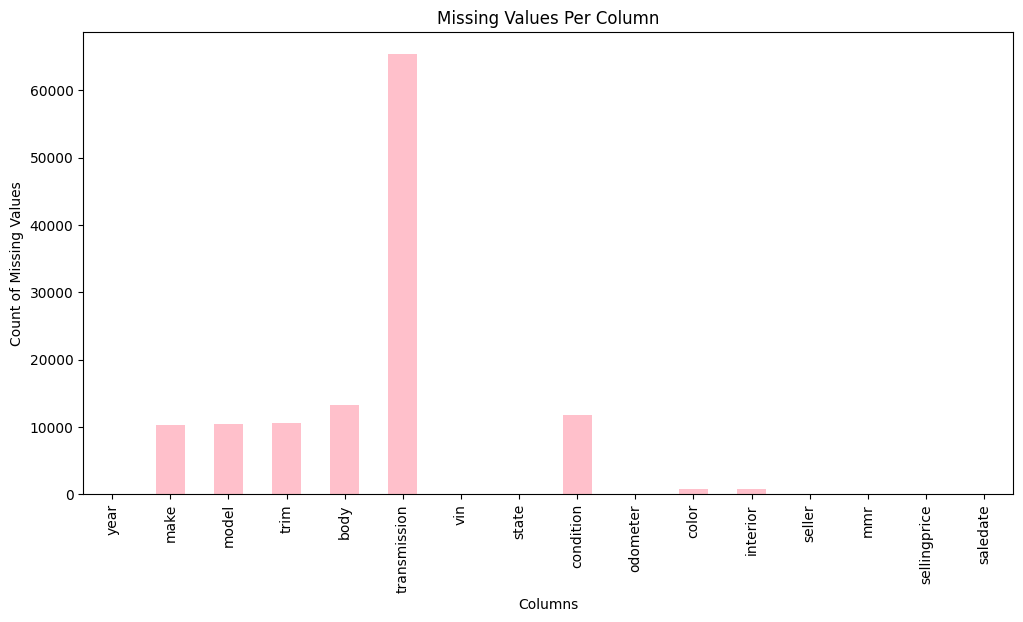

In [18]:
import matplotlib.pyplot as plt

# Bar chart for missing values

plt.figure(figsize=(12,6))

df_car_prices.isnull().sum().plot(kind='bar', color='pink')

plt.title('Missing Values Per Column')

plt.xlabel('Columns')
plt.ylabel('Count of Missing Values')

plt.xticks(rotation=90)

plt.show()

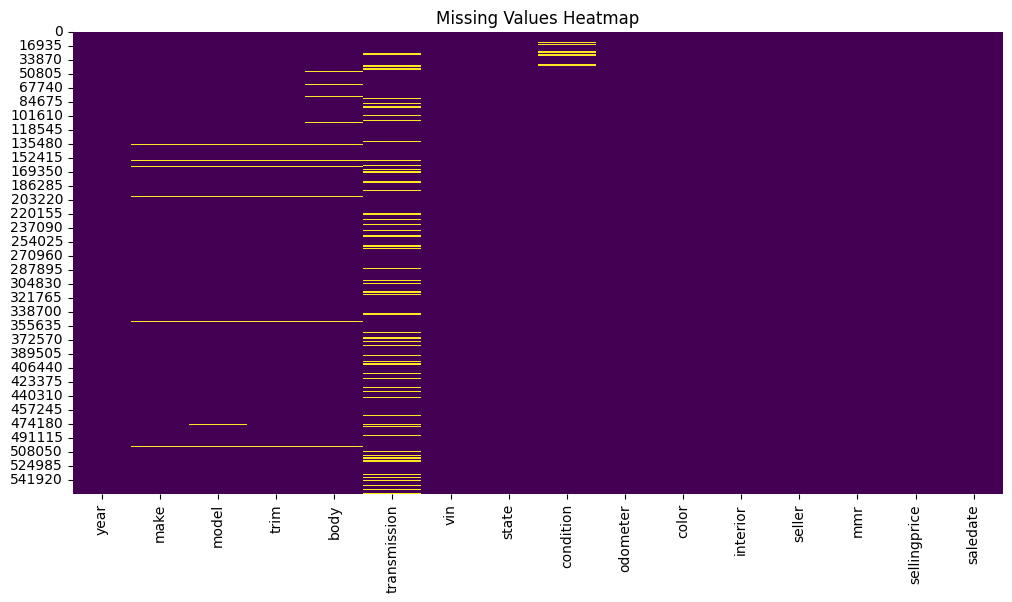

In [19]:
# Heatmap for missing values

plt.figure(figsize=(12,6))

sns.heatmap(df_car_prices.isnull(), cbar=False, cmap='viridis')

plt.title('Missing Values Heatmap')

plt.show()

In [20]:
# Fill numerical null values with median

num_cols = ['condition', 'odometer', 'mmr', 'sellingprice']

for col in num_cols:
    df_car_prices[col].fillna(df_car_prices[col].median(), inplace=True)

/tmp/ipykernel_1829/4188619101.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_car_prices[col].fillna(df_car_prices[col].median(), inplace=True)


In [21]:
# Fill categorical null values with mode

cat_cols = ['make', 'model', 'trim', 'body',
            'transmission', 'color',
            'interior', 'seller', 'state']

for col in cat_cols:
    df_car_prices[col].fillna(df_car_prices[col].mode()[0], inplace=True)

/tmp/ipykernel_1829/1603163615.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_car_prices[col].fillna(df_car_prices[col].mode()[0], inplace=True)


In [22]:
# Check missing values after treatment

df_car_prices.isnull().sum()

,0
year,0
make,0
model,0
trim,0
body,0
transmission,0
vin,4
state,0
condition,0
odometer,0


### Missing Value Treatment Strategy

- Numerical columns were imputed using Median because it is robust against outliers.
- Categorical columns were imputed using Mode because it represents the most frequent category.
- This approach preserves data distribution while minimizing information loss.


In [60]:
# Check duplicate records
duplicate_count = df_car_prices.duplicated().sum()

print("Duplicate Records:", duplicate_count)

# Remove duplicates
df_car_prices = df_car_prices.drop_duplicates()

print("Shape after removing duplicates:", df_car_prices.shape)

Duplicate Records: 0
Shape after removing duplicates: (558837, 17)


In [24]:
# Final cleaned dataset info

df_car_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          558837 non-null  object 
 2   model         558837 non-null  object 
 3   trim          558837 non-null  object 
 4   body          558837 non-null  object 
 5   transmission  558837 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     558837 non-null  float64
 9   odometer      558837 non-null  float64
 10  color         558837 non-null  object 
 11  interior      558837 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558837 non-null  float64
 14  sellingprice  558837 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [25]:
# Save cleaned dataset

df_car_prices.to_csv('cleaned_car_prices.csv', index=False)

# Data Frame Queries


In [26]:
# Average, Minimum and Maximum Selling Price

print("Average Car Price:", df_car_prices['sellingprice'].mean())

print("Minimum Car Price:", df_car_prices['sellingprice'].min())

print("Maximum Car Price:", df_car_prices['sellingprice'].max())


Average Car Price: 13611.326356343621
Minimum Car Price: 1.0
Maximum Car Price: 230000.0


In [27]:
# Unique colors of cars and their counts

color_counts = df_car_prices['color'].value_counts().reset_index()
color_counts.columns = ['Color', 'Count']
display(color_counts)

,Color,Count
0,black,111719
1,white,106673
2,silver,83389
3,gray,82857
4,blue,51139
5,red,43569
6,—,24685
7,green,11382
8,gold,11342
9,beige,9222


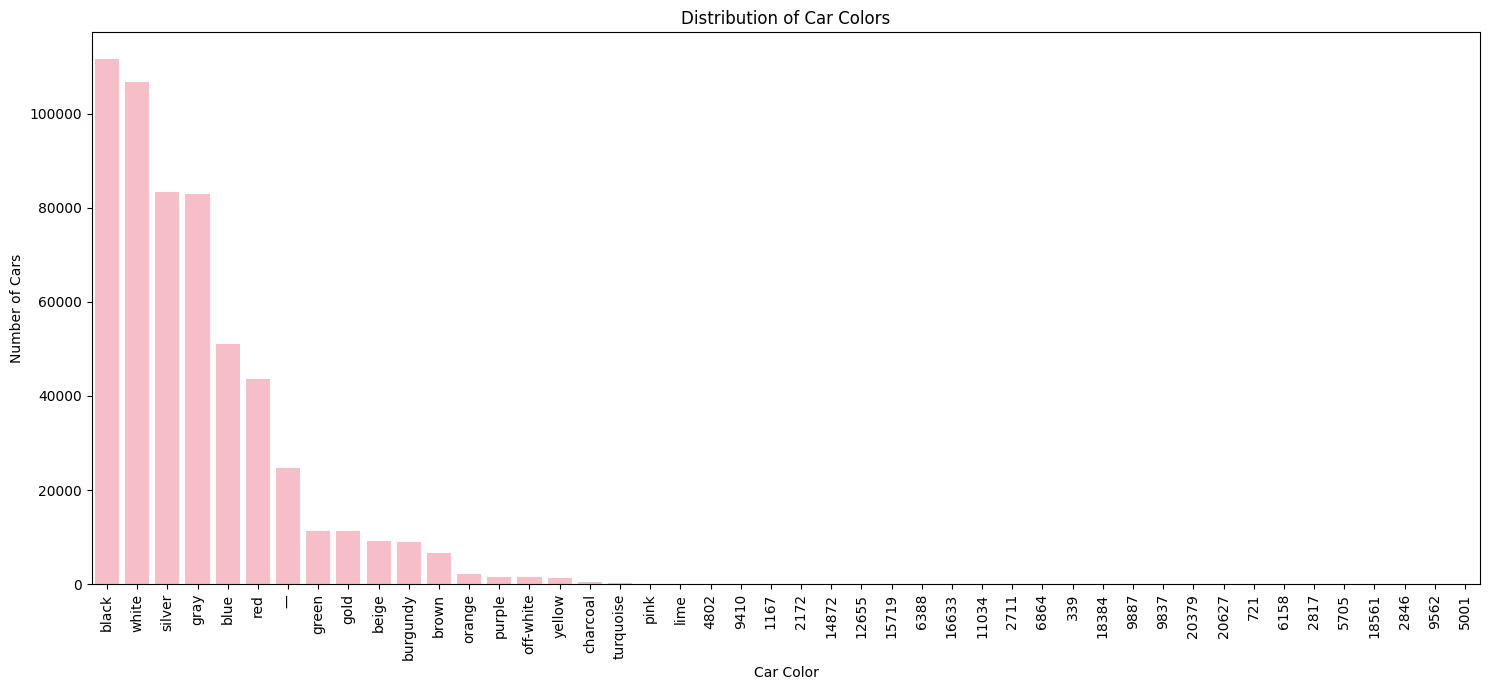

In [28]:
# Bar plot of color counts
plt.figure(figsize=(15, 7))
sns.barplot(x='Color', y='Count', data=color_counts, color='lightpink')
plt.title('Distribution of Car Colors')
plt.xlabel('Car Color')
plt.ylabel('Number of Cars')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [29]:
# Number of unique car brands

print("Unique Car Brands:", df_car_prices['make'].nunique())

# Number of unique car models

print("Unique Car Models:", df_car_prices['model'].nunique())

Unique Car Brands: 96
Unique Car Models: 973


In [30]:
# Cars having selling price greater than 165000

high_price_cars = df_car_prices[df_car_prices['sellingprice'] > 165000]

high_price_cars

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.0,11832.0,white,black,bentley scottsdale,164000.0,169000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


In [31]:
# Top 5 most frequently sold car models

df_car_prices['model'].value_counts().head(5)

,count
model,
Altima,29748
F-150,14479
Fusion,12946
Camry,12545
Escape,11861


In [32]:
# Average selling price by make

avg_price_by_make = df_car_prices.groupby('make')['sellingprice'].mean()

avg_price_by_make.sort_values(ascending=False)

,sellingprice
make,
Rolls-Royce,153488.235294
Ferrari,127210.526316
Lamborghini,112625.000000
Bentley,74367.672414
airstream,71000.000000
...,...
dodge tk,550.000000
Geo,528.947368
dot,500.000000


In [33]:
# Minimum selling price for each interior

min_price_interior = df_car_prices.groupby('interior')['sellingprice'].min()

min_price_interior

,sellingprice
interior,
beige,100.0
black,1.0
blue,150.0
brown,200.0
burgundy,175.0
gold,250.0
gray,1.0
green,100.0
off-white,900.0


In [34]:
# Highest odometer reading per year

highest_odometer = df_car_prices.groupby('year')['odometer'].max()

highest_odometer.sort_values(ascending=False)

,odometer
year,
1997,999999.0
1996,999999.0
2014,999999.0
2013,999999.0
1998,999999.0
1999,999999.0
1993,999999.0
2010,999999.0
2009,999999.0


In [35]:
# Create car_age column

df_car_prices['car_age'] = 2025 - df_car_prices['year']

# Display year and car age

df_car_prices[['year', 'car_age']].head()

,year,car_age
0,2015,10
1,2015,10
2,2014,11
3,2015,10
4,2014,11


In [36]:
# Filter cars based on condition and odometer

filtered_cars = df_car_prices[
    (df_car_prices['condition'] >= 48) &
    (df_car_prices['odometer'] > 90000)
]

# Count filtered cars

print("Number of Cars:", filtered_cars.shape[0])

Number of Cars: 746


In [37]:
# Filter newer cars

newer_cars = df_car_prices[df_car_prices['year'] > 2013]

# Average selling price by state

state_prices = newer_cars.groupby('state')['sellingprice'].mean()

# Sort from highest to lowest

state_prices.sort_values(ascending=False)

,sellingprice
state,
oh,28020.221053
ab,25204.255319
nj,24237.063973
on,22962.560386
qc,22722.938144
...,...
3vwd17aj5fm225953,13200.000000
3vwd17aj8fm239622,13200.000000
3vwd17aj3fm276741,13200.000000


In [38]:
# Find top 20% condition threshold

condition_threshold = df_car_prices['condition'].quantile(0.80)

# Filter excellent condition cars

excellent_cars = df_car_prices[
    df_car_prices['condition'] >= condition_threshold
]

# Average price by make

value_for_money = excellent_cars.groupby('make')['sellingprice'].mean()

# Lowest average price first

value_for_money.sort_values().head(10)

,sellingprice
make,
Isuzu,1125.000000
Oldsmobile,1910.000000
honda,4233.333333
Saturn,5700.406504
subaru,6200.000000
chrysler,6225.000000
smart,6835.759494
mazda,7275.000000
Pontiac,7686.824324


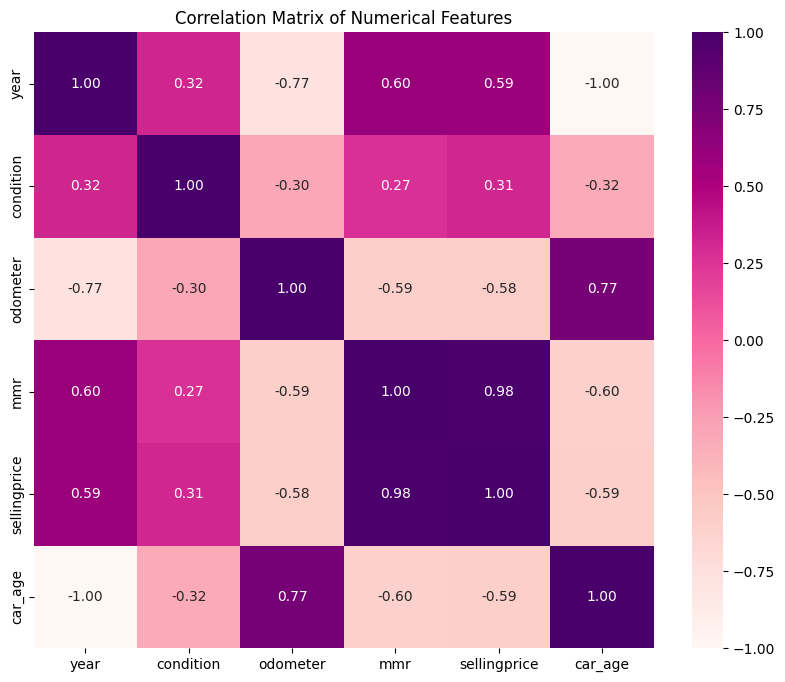

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
# Select numerical columns

numerical_columns = df_car_prices.select_dtypes(include=['int64', 'float64'])

# Correlation matrix

correlation_matrix = numerical_columns.corr()

# Plot heatmap

plt.figure(figsize=(10,8))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='RdPu',
            fmt='.2f')

plt.title('Correlation Matrix of Numerical Features')

plt.show()

In [62]:
correlation_matrix['sellingprice']\
.sort_values(ascending=False)

,sellingprice
sellingprice,1.000000
mmr,0.983634
year,0.586474
condition,0.313120
odometer,-0.582267
car_age,-0.586474


Positive correlation with year
Negative correlation with odometer
Relationship with condition

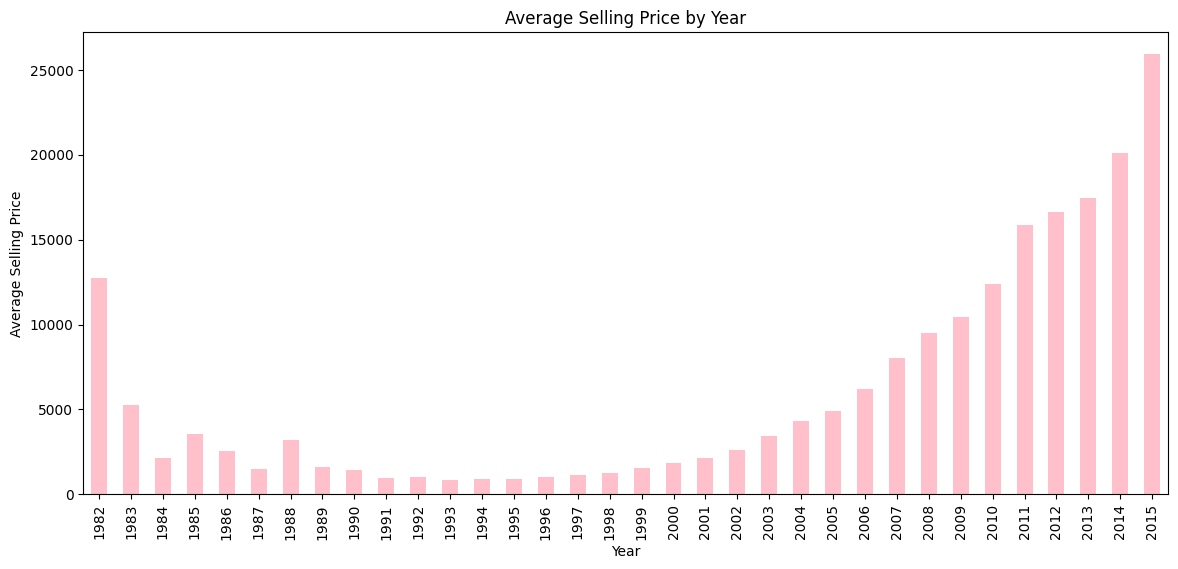

In [40]:
import matplotlib.pyplot as plt

# Average selling price by year

avg_price_year = df_car_prices.groupby('year')['sellingprice'].mean()

# Plot

plt.figure(figsize=(14,6))

avg_price_year.plot(kind='bar', color='Pink')

plt.title('Average Selling Price by Year')

plt.xlabel('Year')

plt.ylabel('Average Selling Price')

plt.show()

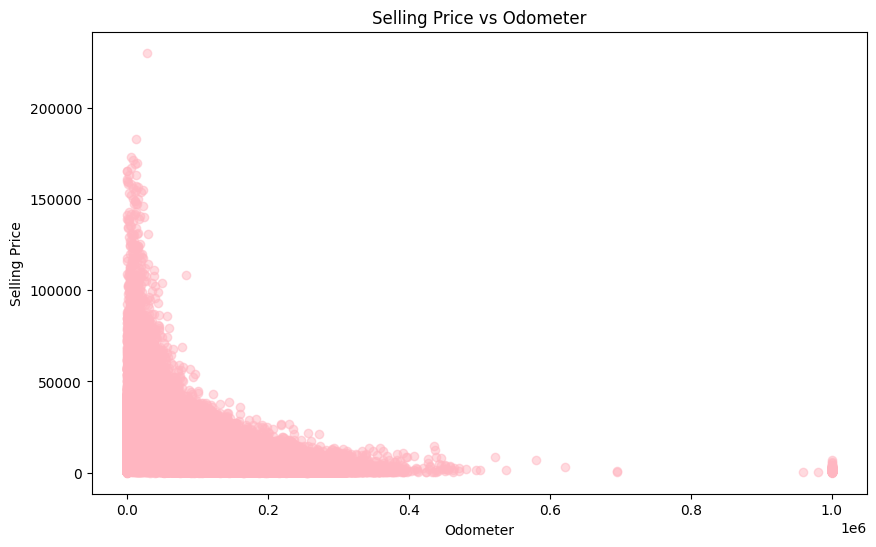

In [41]:
# Scatter plot of odometer vs selling price

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(df_car_prices['odometer'],
            df_car_prices['sellingprice'],
            alpha=0.5,
            color='lightpink')

plt.title('Selling Price vs Odometer')

plt.xlabel('Odometer')

plt.ylabel('Selling Price')

plt.show()

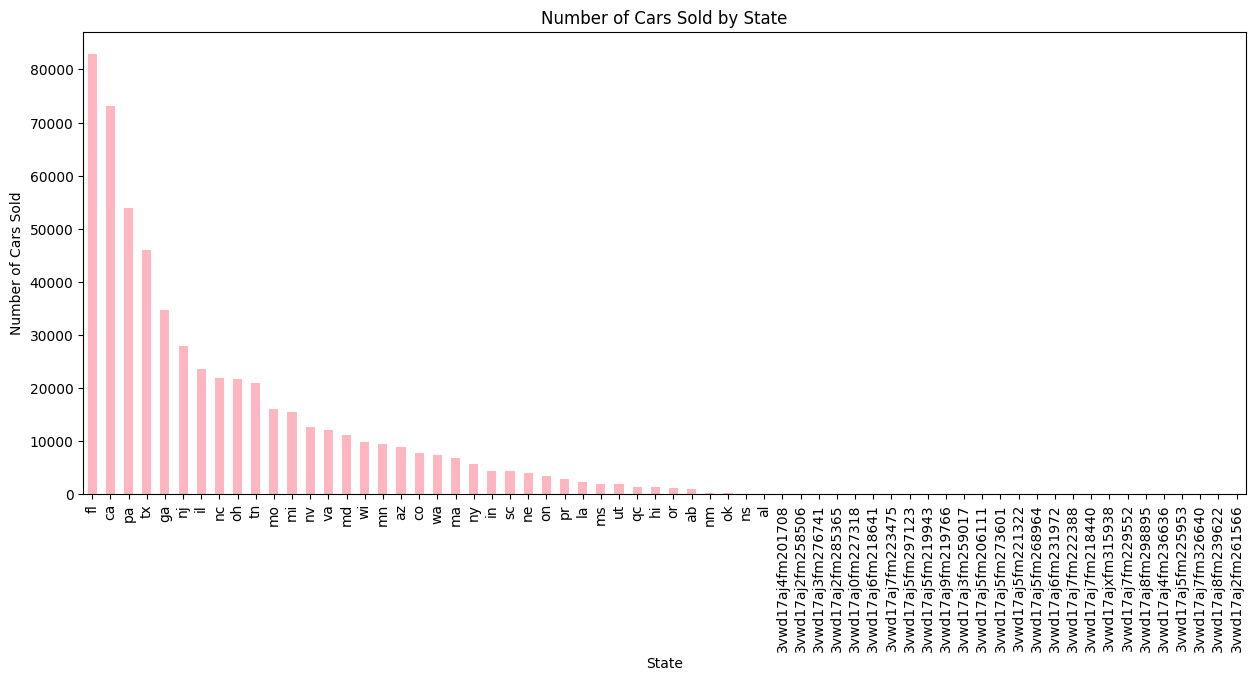

In [42]:
import matplotlib.pyplot as plt

# Cars sold by state

cars_by_state = df_car_prices['state'].value_counts()

# Plot

plt.figure(figsize=(15,6))

cars_by_state.plot(kind='bar', color='lightpink')

plt.title('Number of Cars Sold by State')

plt.xlabel('State')

plt.ylabel('Number of Cars Sold')

plt.show()

In [43]:
# Top 3 car selling states

cars_by_state.head(3)

,count
state,
fl,82945
ca,73148
pa,53907


In [44]:
import pandas as pd

# Create condition bins

df_car_prices['condition_range'] = pd.cut(
    df_car_prices['condition'],
    bins=range(0, 105, 5)
)

In [45]:
# Average price by condition range

avg_price_condition = df_car_prices.groupby(
    'condition_range'
)['sellingprice'].mean()

/tmp/ipykernel_1829/2868116431.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_condition = df_car_prices.groupby(


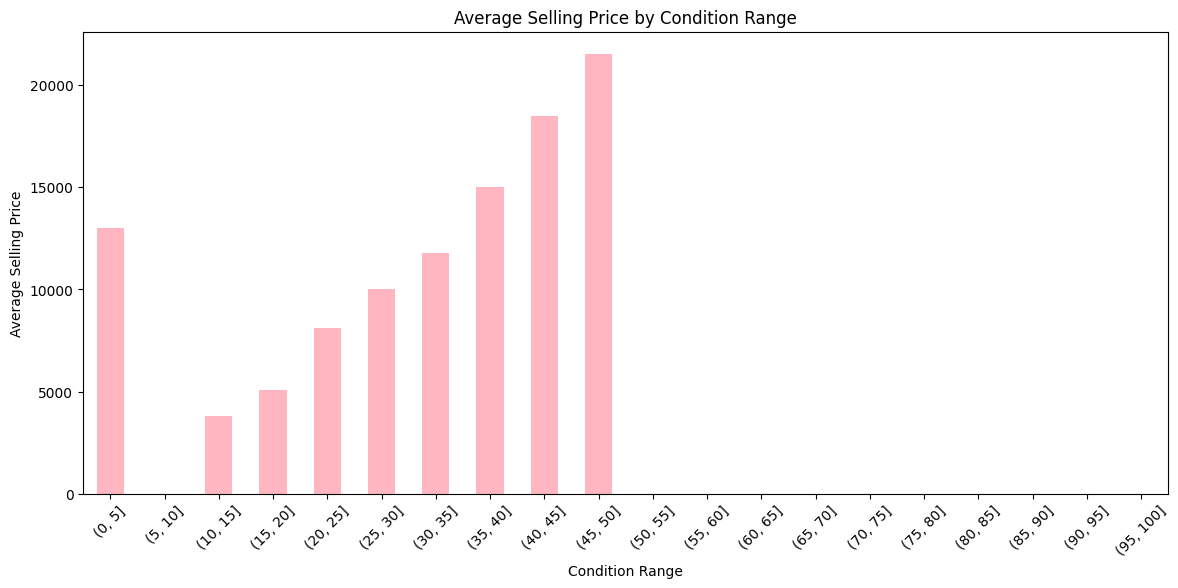

In [46]:
# Plot graph

plt.figure(figsize=(14,6))

avg_price_condition.plot(kind='bar', color='lightpink')

plt.title('Average Selling Price by Condition Range')

plt.xlabel('Condition Range')

plt.ylabel('Average Selling Price')

plt.xticks(rotation=45)

plt.show()

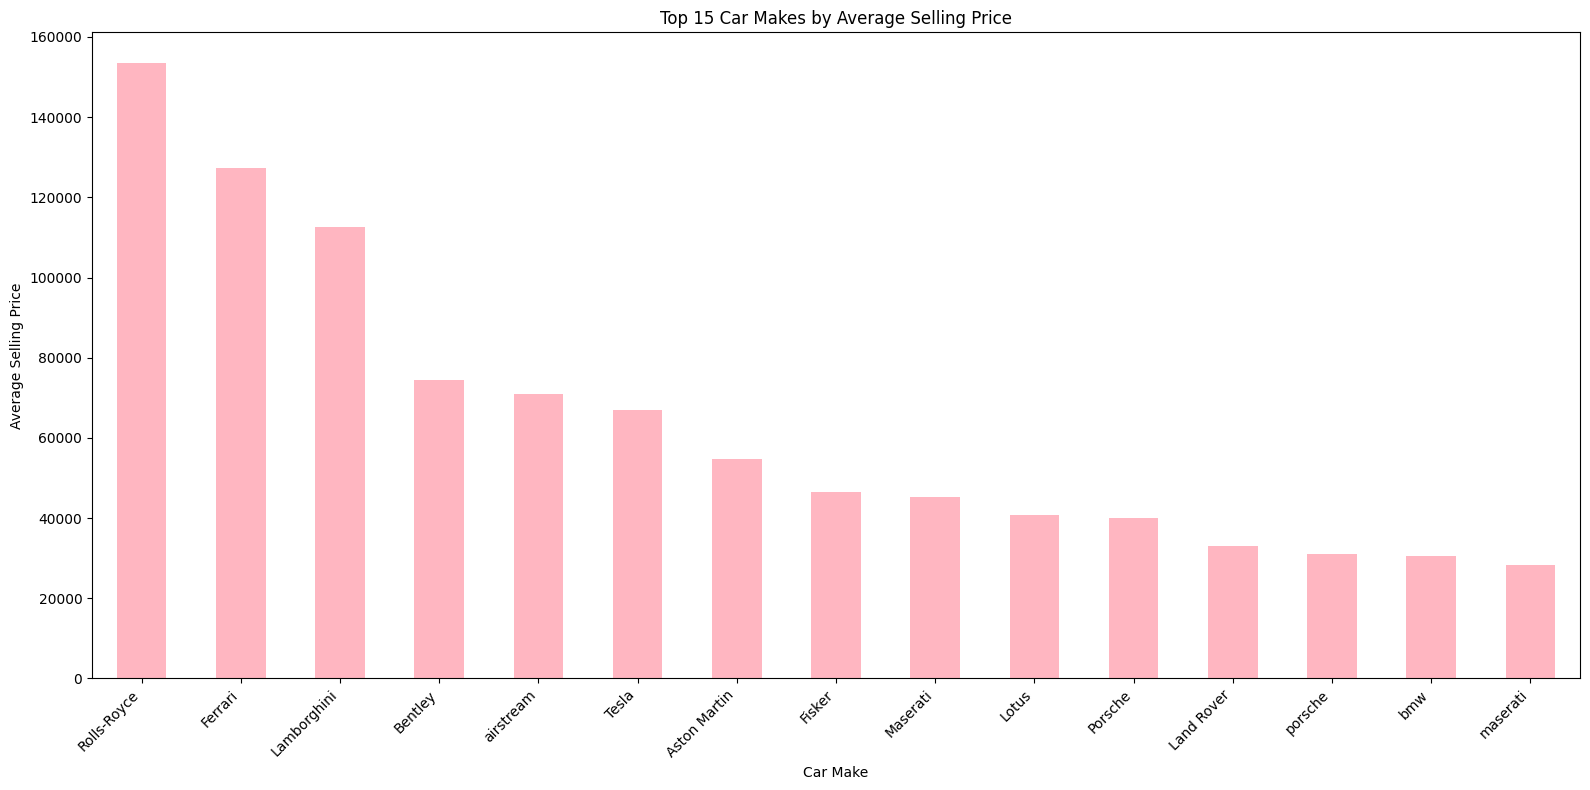

In [47]:
# Plot graph for average selling price by make

plt.figure(figsize=(16, 8))

avg_price_by_make.sort_values(ascending=False).head(15).plot(kind='bar', color='lightpink')

plt.title('Top 15 Car Makes by Average Selling Price')

plt.xlabel('Car Make')

plt.ylabel('Average Selling Price')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()

Most cars are concentrated in medium to high condition ranges. Very low-condition cars are less frequently sold.

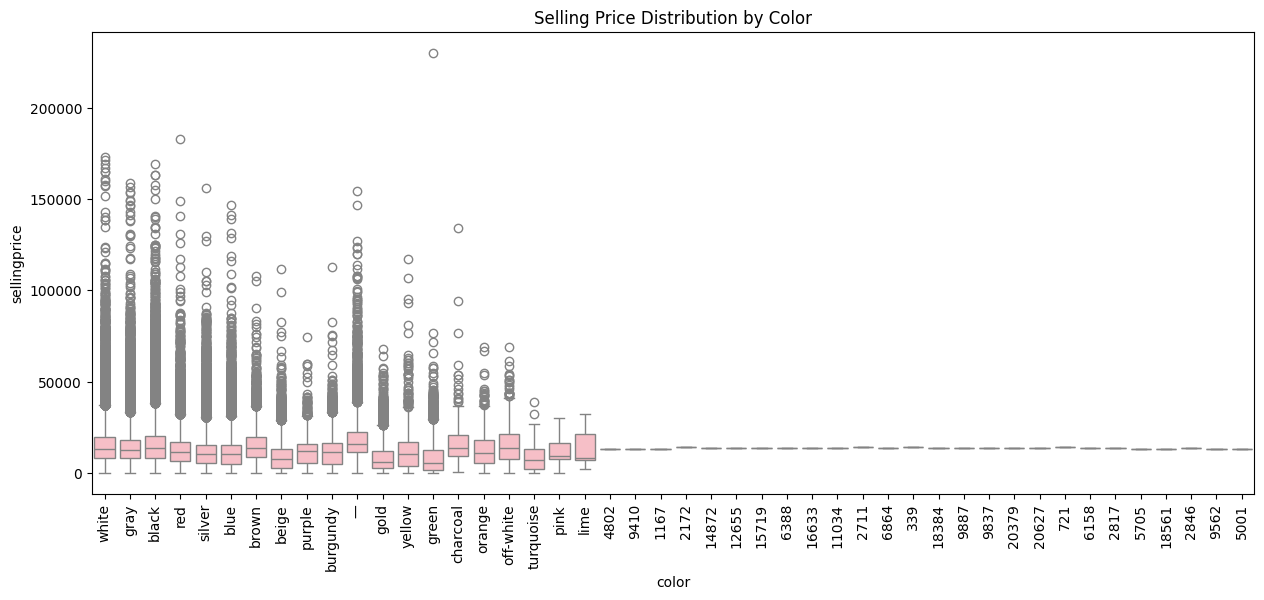

In [53]:
# Box plot of selling price by color
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,6))

sns.boxplot(
    x='color',
    y='sellingprice',
    data=df_car_prices,
    color='lightpink'
)

plt.title('Selling Price Distribution by Color')

plt.xticks(rotation=90)

plt.show()

Some car colors have higher price variations. Luxury cars in certain colors create extreme outliers.

In [54]:
# Calculate Q1 and Q3

Q1 = df_car_prices['sellingprice'].quantile(0.25)

Q3 = df_car_prices['sellingprice'].quantile(0.75)

# Calculate IQR

IQR = Q3 - Q1

# Lower and Upper Limits

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

# Remove outliers

df_no_outliers = df_car_prices[
    (df_car_prices['sellingprice'] >= lower_limit) &
    (df_car_prices['sellingprice'] <= upper_limit)
]

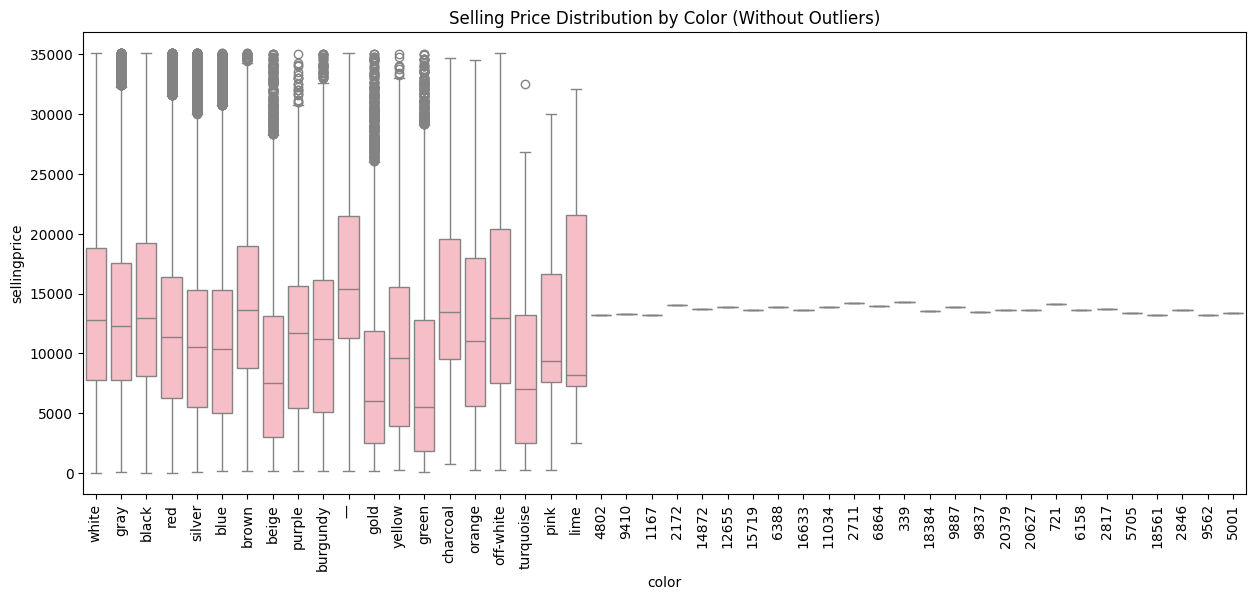

In [56]:
plt.figure(figsize=(15,6))

sns.boxplot(
    x='color',
    y='sellingprice',
    data=df_no_outliers,
    color='lightpink'
)

plt.title('Selling Price Distribution by Color (Without Outliers)')

plt.xticks(rotation=90)

plt.show()

### Descriptive Statistics of Selling Price by Color (Without Outliers)

To provide a more analytical view, here are the key statistics (mean, standard deviation, min, max, quartiles) of selling prices grouped by car color, after removing outliers. This helps in understanding the central tendency and spread of prices for each color numerically.

In [57]:
color_price_stats = df_no_outliers.groupby('color')['sellingprice'].describe()
display(color_price_stats.sort_values(by='mean', ascending=False))

,count,mean,std,min,25%,50%,75%,max
color,,,,,,,,
—,23537.0,16436.961550,7247.545293,200.0,11250.0,15400.0,21500.0,35100.0
charcoal,461.0,14770.284165,7567.749784,800.0,9500.0,13500.0,19600.0,34700.0
339,1.0,14300.000000,NaN,14300.0,14300.0,14300.0,14300.0,14300.0
2711,1.0,14250.000000,NaN,14250.0,14250.0,14250.0,14250.0,14250.0
brown,6438.0,14110.711712,7828.496029,200.0,8800.0,13600.0,19000.0,35100.0
off-white,1390.0,14108.635252,8389.009967,300.0,7500.0,13000.0,20400.0,35100.0
721,1.0,14100.000000,NaN,14100.0,14100.0,14100.0,14100.0,14100.0
2172,1.0,14050.000000,NaN,14050.0,14050.0,14050.0,14050.0,14050.0
6864,1.0,14000.000000,NaN,14000.0,14000.0,14000.0,14000.0,14000.0


After removing outliers, the distribution becomes more balanced and easier to compare across colors.

#Dashboard Insights

Newer cars generally have higher selling prices.
High mileage reduces resale value.
Certain states dominate used car sales.
Car condition strongly impacts pricing.
Some brands appear more frequently due to higher market demand.

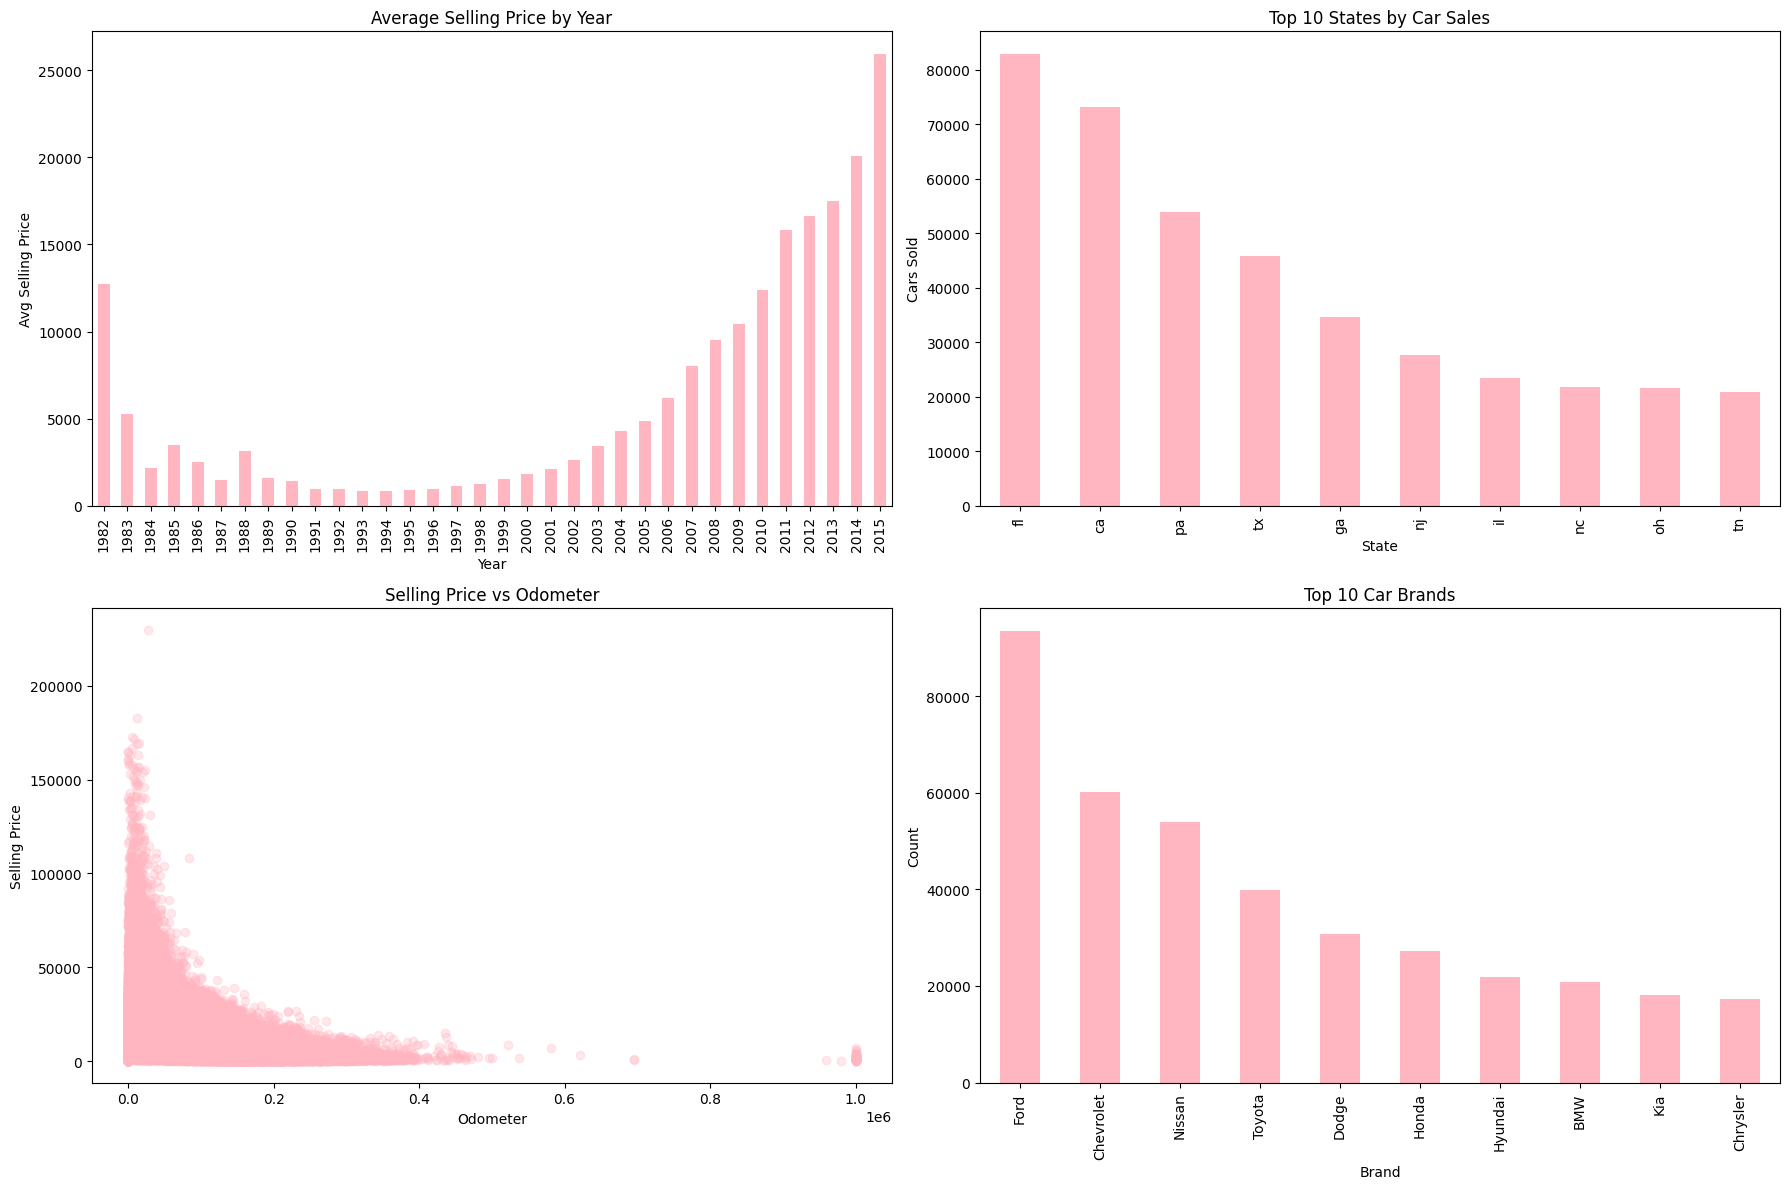

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ---------------------------------------------
# 1. Average Selling Price by Year
# ---------------------------------------------

avg_price_year = df_car_prices.groupby('year')['sellingprice'].mean()

avg_price_year.plot(
    kind='bar',
    ax=axes[0,0],
    color='lightpink' # Applied lightpink color
)

axes[0,0].set_title('Average Selling Price by Year')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Avg Selling Price')

# ---------------------------------------------
# 2. Cars Sold by State
# ---------------------------------------------

state_sales = df_car_prices['state'].value_counts().head(10)

state_sales.plot(
    kind='bar',
    ax=axes[0,1],
    color='lightpink' # Applied lightpink color
)
axes[0,1].set_title('Top 10 States by Car Sales')
axes[0,1].set_xlabel('State')
axes[0,1].set_ylabel('Cars Sold')

# ---------------------------------------------
# 3. Selling Price vs Odometer
# ---------------------------------------------

axes[1,0].scatter(
    df_car_prices['odometer'],
    df_car_prices['sellingprice'],
    alpha=0.3,
    color='lightpink' # Applied lightpink color
)

axes[1,0].set_title('Selling Price vs Odometer')
axes[1,0].set_xlabel('Odometer')
axes[1,0].set_ylabel('Selling Price')
# ---------------------------------------------
# 4. Top 10 Car Brands
# ---------------------------------------------

top_brands = df_car_prices['make'].value_counts().head(10)

top_brands.plot(
    kind='bar',
    ax=axes[1,1],
    color='lightpink' # Applied lightpink color
)

axes[1,1].set_title('Top 10 Car Brands')
axes[1,1].set_xlabel('Brand')
axes[1,1].set_ylabel('Count')

# ---------------------------------------------
# Dashboard Layout
# ---------------------------------------------

plt.tight_layout()

plt.show()

### Dashboard Insights

Here are some analytical insights derived from the dashboard:

1.  **Average Selling Price by Year:** This plot clearly illustrates the trend of average car selling prices over different years. Generally, newer cars (higher year values) tend to have higher average selling prices, indicating depreciation over time. There might be some fluctuations, which could be due to economic factors, specific model releases, or changes in market demand.

2.  **Top 10 States by Car Sales:** This bar chart highlights the states with the highest volume of car sales. This information is valuable for identifying key markets or regions where car demand is particularly high. States like Florida (fl), California (ca), and Pennsylvania (pa) appear to be dominant in terms of the number of cars sold.

3.  **Selling Price vs Odometer:** This scatter plot shows the relationship between a car's odometer reading (mileage) and its selling price. A general trend of decreasing selling price with increasing odometer readings is evident, reflecting that cars with higher mileage typically command lower prices due to wear and tear. The density of points can also reveal common mileage ranges for certain price points.

4.  **Top 10 Car Brands:** This bar chart displays the ten most frequently sold car brands. This indicates popular brands in the used car market, which can be useful for inventory management, marketing strategies, or understanding brand influence on sales volume. Brands like Nissan (Altima), Ford (F-150, Fusion, Escape), and Toyota (Camry) are among the most frequently sold.

## Final Project Conclusion

This project embarked on a comprehensive analysis of used car sales data, employing a robust methodology that encompassed data cleaning, exploratory data analysis (EDA), advanced visualization, and dashboard creation. Utilizing Python libraries such as Pandas for data manipulation, Matplotlib and Seaborn for visualization, we transformed raw data into actionable insights.

**Key Stages and Outcomes:**

1.  **Data Cleaning and Preprocessing:** We meticulously addressed missing values by imputing numerical columns with medians and categorical columns with modes, ensuring data integrity. Duplicate entries were handled, and relevant features like `car_age` were engineered to enrich the dataset.

2.  **Exploratory Data Analysis (EDA):** Through statistical summaries and initial plots, we gained a foundational understanding of the data's distribution, central tendencies, and potential anomalies. This phase was crucial for identifying trends before deep-diving into specific questions.

3.  **Visualization and Insight Generation:** A variety of visualizations were created to illuminate different facets of the data:
    *   **Selling Price Trends:** We observed clear relationships between `sellingprice` and `year`, `odometer` readings, and `condition` (e.g., newer cars with lower mileage and better condition generally commanded higher prices).
    *   **Geographic and Brand Insights:** Visualizations highlighted the top states for car sales and the most frequently sold car brands, indicating regional market strengths and brand popularity.
    *   **Color Distribution and Impact:** An analysis of car colors revealed the most common choices and how color, even after outlier removal, could influence selling price distributions, with certain colors showing more price variance.

4.  **Interactive Dashboard Creation:** A consolidated dashboard was developed to present key findings cohesively. This allowed for a multi-dimensional view of factors influencing car sales and pricing, such as average selling price by year, cars sold by state, selling price versus odometer, and top car brands.

**Overall Impact:**

This project successfully demonstrated a practical application of data science techniques in understanding a complex dataset. The insights derived provide valuable intelligence for stakeholders in the used car market, aiding in strategic decision-making related to pricing, inventory management, marketing, and identifying high-value market segments. The robust data preprocessing and analytical visualizations lay a strong foundation for potential future work, such as predictive modeling to forecast car prices or identify optimal selling strategies.

## Business Recommendations

1. Newer vehicles command higher resale values.
2. Vehicle condition significantly influences price.
3. High mileage reduces market value.
4. Top-selling states should receive greater inventory allocation.
5. Brands offering lower average prices with high condition scores represent value-for-money opportunities.